<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Price_Pedict_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [156]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')


## Declare data columns Lists

In [158]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

dropping 'Listing ID'and duplciated'Neighbourhood Grouped'

In [159]:
df = df_EDA2.copy()
df = df.drop(columns=['review_date', 'Host Since'])

In [160]:
df.shape, df.index[-1]

((23536, 31), 23535)

In [161]:
df.reset_index(drop=True, inplace=True)
df.shape, df.index[-1]

((23536, 31), 23535)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accomodates            23536 non-null  float64
 1   Accuracy Rating        18888 non-null  float64
 2   Bathrooms              23507 non-null  float64
 3   Bedrooms               23516 non-null  float64
 4   Beds                   23501 non-null  float64
 5   Checkin Rating         18870 non-null  float64
 6   Cleanliness Rating     18892 non-null  float64
 7   Communication Rating   18886 non-null  float64
 8   Guests Included        23536 non-null  float64
 9   Host Response Rate     13046 non-null  float64
 10  Latitude               23536 non-null  float64
 11  Location Rating        18871 non-null  float64
 12  Longitude              23536 non-null  float64
 13  Min Nights             23536 non-null  float64
 14  Overall Rating         18914 non-null  float64
 15  Pr

In [163]:
df_num = df._get_numeric_data().dropna()
df_num.shape

(297, 22)

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

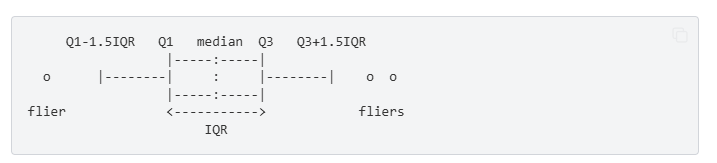

In [164]:
df_num_non_dummy = df_num.drop(columns=boolean_columns)
num_non_dummy_columns = df_num_non_dummy.columns
df_num_non_dummy.shape
num_non_dummy_columns

Index(['Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms', 'Beds',
       'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude', 'Location Rating',
       'Longitude', 'Min Nights', 'Overall Rating', 'Price', 'Reviews',
       'Square Feet', 'Value Rating'],
      dtype='object')

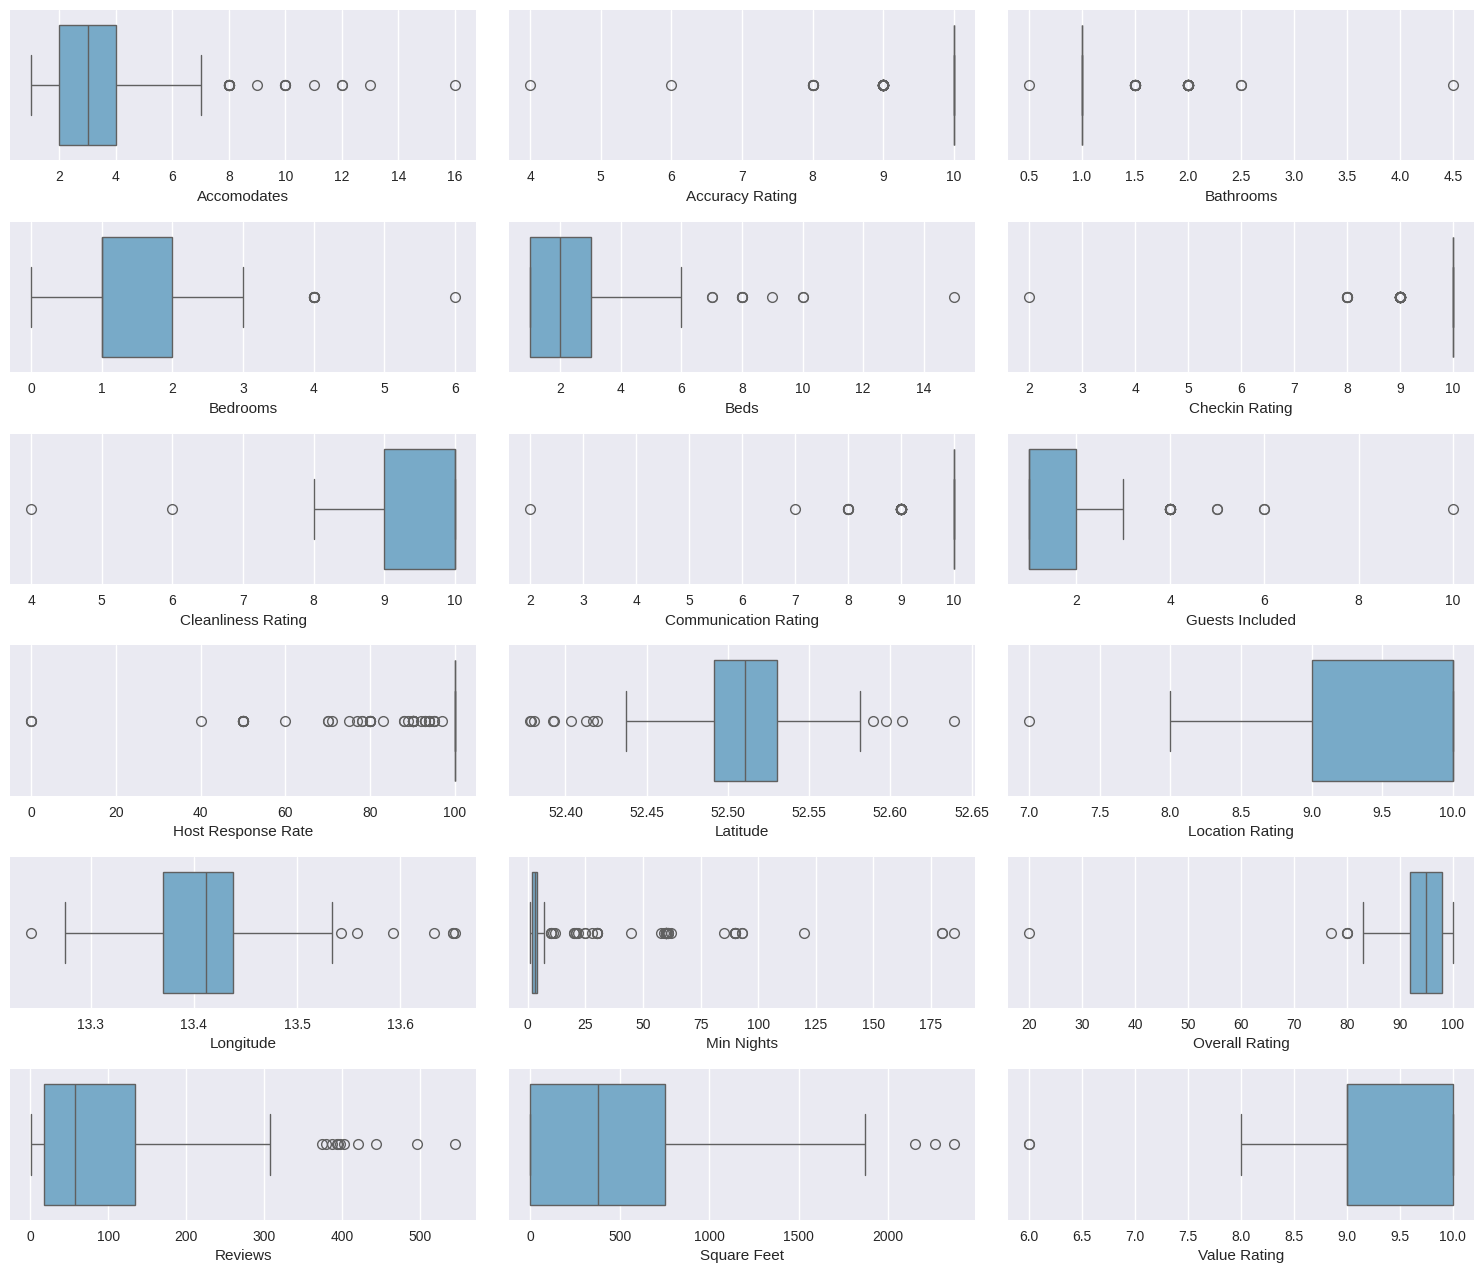

In [165]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 40))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 3, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num_non_dummy)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Ignored as it is the target value
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [166]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in df_num_non_dummy:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=num_non_dummy_columns)

df_describe(df_num_non_dummy, num_non_dummy_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accomodates,1.00000,2.00000,3.00000,4.00000,16.00000,2.00000,-1.000000,7.000000
Accuracy Rating,4.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Bathrooms,0.50000,1.00000,1.00000,1.00000,4.50000,0.00000,1.000000,1.000000
Bedrooms,0.00000,1.00000,1.00000,2.00000,6.00000,1.00000,-0.500000,3.500000
Beds,1.00000,1.00000,2.00000,3.00000,15.00000,2.00000,-2.000000,6.000000
Checkin Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Cleanliness Rating,4.00000,9.00000,10.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Communication Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Guests Included,1.00000,1.00000,1.00000,2.00000,10.00000,1.00000,-0.500000,3.500000
Host Response Rate,0.00000,100.00000,100.00000,100.00000,100.00000,0.00000,100.000000,100.000000


## Data Cleansing

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [167]:
def count_outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])
    # for col in df:  # Ensure processing numeric columns only
    for col in [c for c in df if c != 'Price']:  # Ensure processing numeric columns only and exclude Price
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

**Consider replacing outliers_df dataframe with only outliers_df_columns**

In [168]:
len(df_num_non_dummy.columns)

19

In [169]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = count_outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df, outliers_df.shape

(                      Outlier count    Percent
 Accuracy Rating                74.0  24.915825
 Checkin Rating                 60.0  20.202020
 Host Response Rate             56.0  18.855219
 Min Nights                     53.0  17.845118
 Bathrooms                      52.0  17.508418
 Communication Rating           51.0  17.171717
 Guests Included                26.0   8.754209
 Accomodates                    20.0   6.734007
 Latitude                       13.0   4.377104
 Reviews                        11.0   3.703704
 Beds                           10.0   3.367003
 Bedrooms                        9.0   3.030303
 Longitude                       8.0   2.693603
 Overall Rating                  5.0   1.683502
 Square Feet                     3.0   1.010101
 Cleanliness Rating              2.0   0.673401
 Value Rating                    2.0   0.673401
 Location Rating                 1.0   0.336700,
 (18, 2))

In [170]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers - labeling with 'Outlier'
Labeling every outlier with 'Outlier'

In [171]:
outliers_df.index

Index(['Accuracy Rating', 'Checkin Rating', 'Host Response Rate', 'Min Nights',
       'Bathrooms', 'Communication Rating', 'Guests Included', 'Accomodates',
       'Latitude', 'Reviews', 'Beds', 'Bedrooms', 'Longitude',
       'Overall Rating', 'Square Feet', 'Cleanliness Rating', 'Value Rating',
       'Location Rating'],
      dtype='object')

In [172]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit, 'Outlier',
                                         np.where(label_out_df[col] < lower_limit,
                                                  'Outlier', label_out_df[col]))
    return label_out_df

new_df_outliers = outliers(df)
new_df_outliers.head(5)

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Square Feet,Value Rating,Comments,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Property Type Reduced,Postal Code Reduced
0,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,Outlier,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,nan,10.0,I really enjoyed staying at Micha and Nadja's ...,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Apartment,10
1,4.0,Outlier,1.0,1.0,2.0,Outlier,9.0,Outlier,Outlier,Outlier,52.535,10.0,13.41758,Outlier,92.0,90.0,Outlier,720.0,9.0,"excellent stay, i would highly recommend it. a...",within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Apartment,10
2,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,Outlier,nan,10.0,I could not have asked for a better place to s...,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Apartment,10
3,Outlier,10.0,Outlier,Outlier,Outlier,10.0,10.0,10.0,Outlier,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,nan,10.0,The host was very welcoming and hospitable. He...,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Apartment,10
4,1.0,10.0,1.0,Outlier,1.0,Outlier,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,Outlier,93.0,70.0,23.0,nan,9.0,"We had everything we needed, the apartment was...",within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Apartment,10


### df_outliers - 0/1

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [173]:
df_outliers = new_df_outliers.isin(['Outlier'])
df_outliers = df_outliers.astype('int')
df_outliers

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Square Feet,Value Rating,Comments,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23532,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23533,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23534,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [174]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Square Feet,Value Rating,Comments,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Property Type Reduced,Postal Code Reduced
0,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,NaN,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,NaN,10.0,I really enjoyed staying at Micha and Nadja's ...,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Apartment,10
1,4.0,NaN,1.0,1.0,2.0,NaN,9.0,NaN,NaN,NaN,52.53500,10.0,13.41758,NaN,92.0,90.0,NaN,720.0,9.0,"excellent stay, i would highly recommend it. a...",within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Apartment,10
2,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,NaN,NaN,10.0,I could not have asked for a better place to s...,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Apartment,10
3,NaN,10.0,NaN,NaN,NaN,10.0,10.0,10.0,NaN,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,NaN,10.0,The host was very welcoming and hospitable. He...,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Apartment,10
4,1.0,10.0,1.0,NaN,1.0,NaN,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,NaN,93.0,70.0,23.0,NaN,9.0,"We had everything we needed, the apartment was...",within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Apartment,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,3.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.0,NaN,NaN,None,within a few hours,False,Wannsee,Steglitz - Zehlendorf,14109,False,Apartment,Entire home/apt,True,Apartment,14
23532,2.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.49340,5.0,NaN,30.0,0.0,NaN,NaN,None,None,False,Mitte,Pankow,13125,True,Apartment,Private room,True,Apartment,13
23533,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.45402,NaN,13.43864,2.0,NaN,17.0,0.0,NaN,NaN,None,None,False,Britz,NeukÃ¶lln,12347,True,Apartment,Private room,True,Apartment,12
23534,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,52.47342,NaN,NaN,2.0,NaN,52.0,0.0,NaN,NaN,None,None,False,KÃ¶penick,Treptow - KÃ¶penick,12555,True,Apartment,Entire home/apt,True,Apartment,12


In [175]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

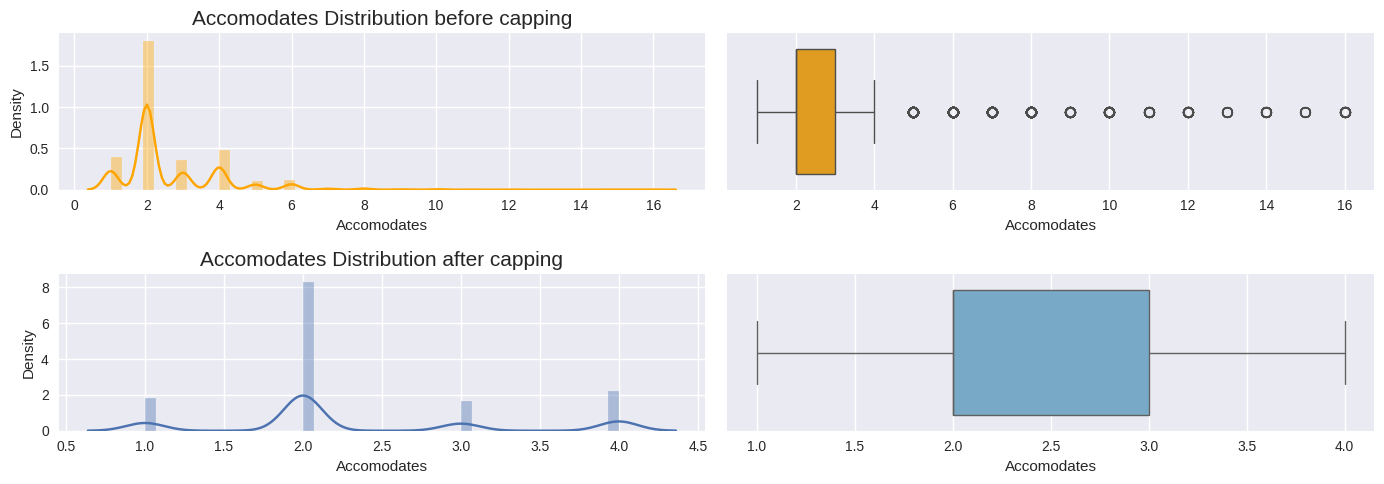

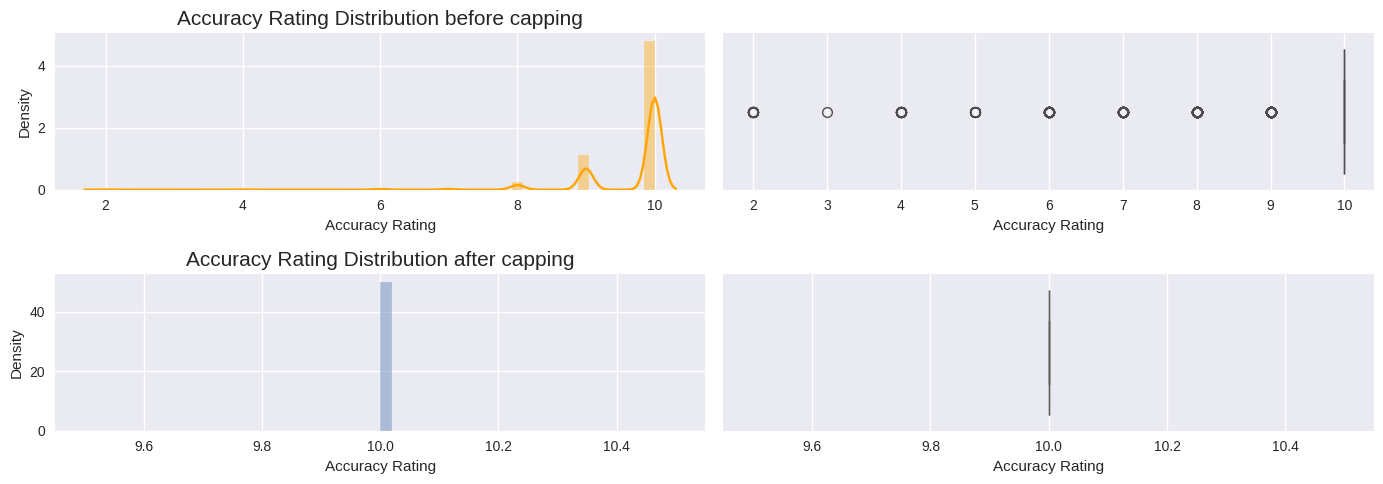

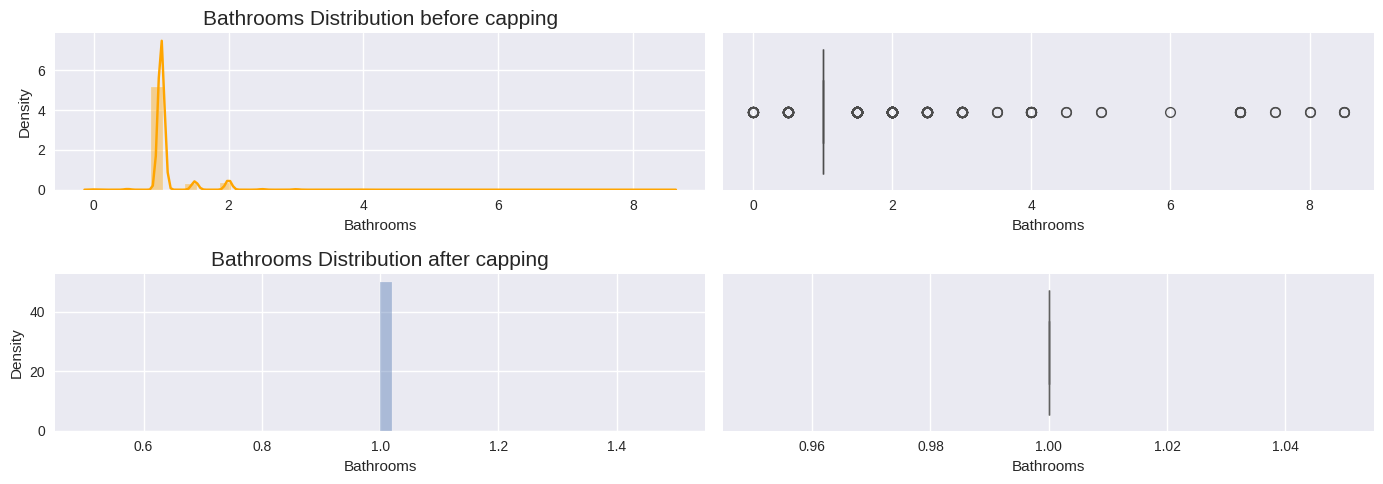

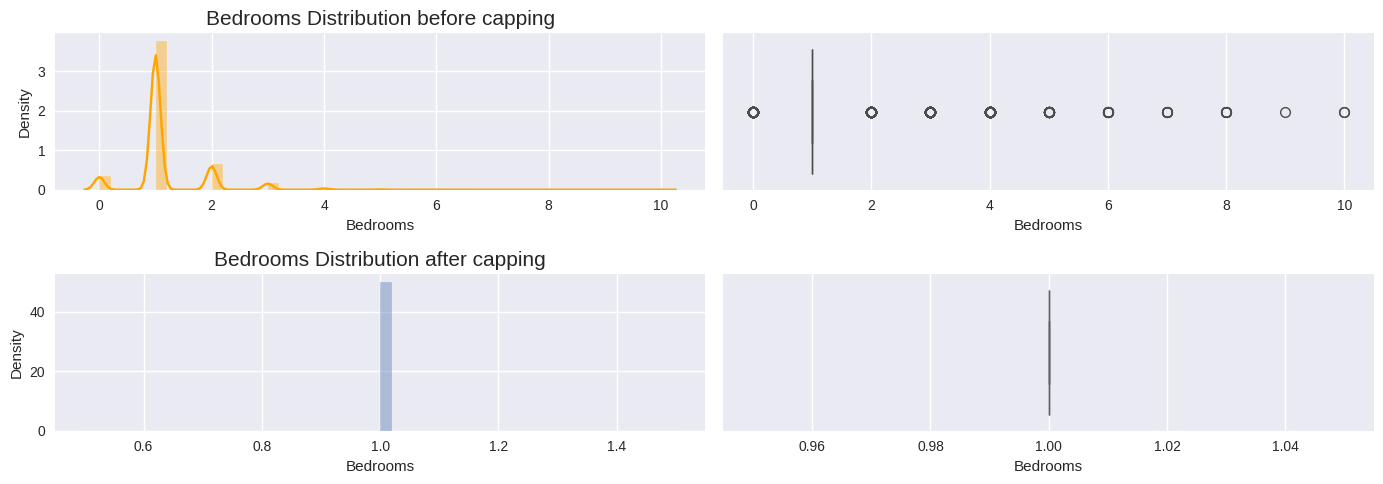

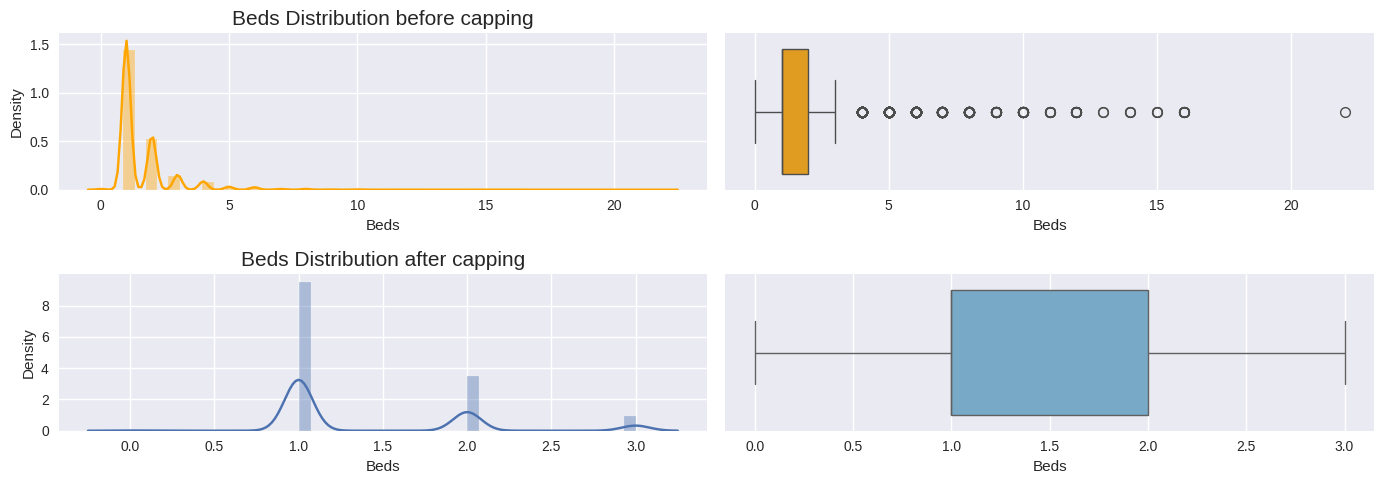

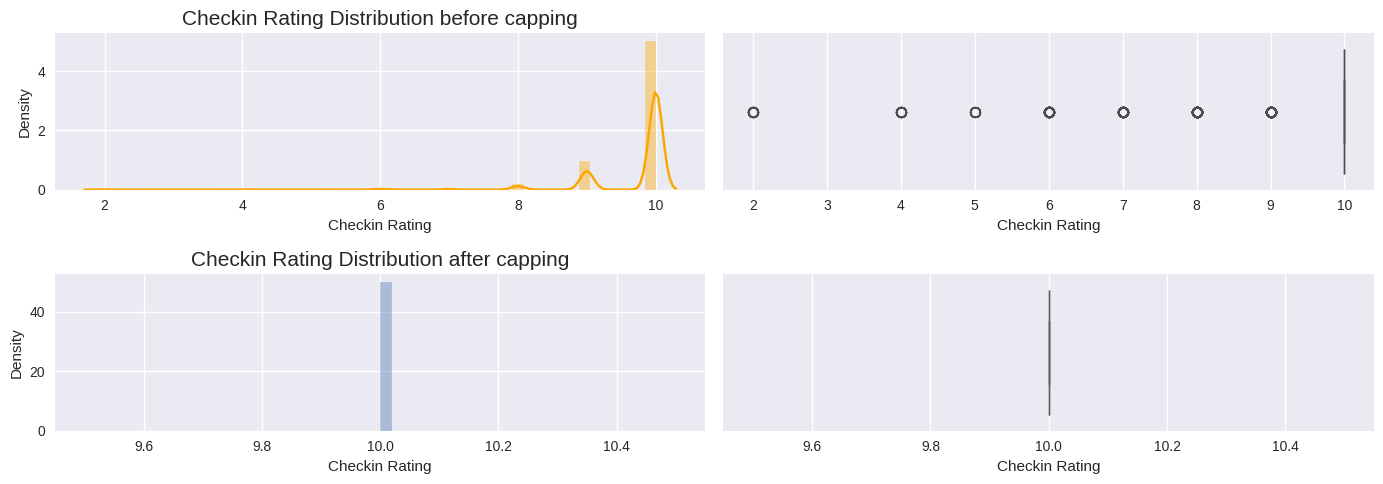

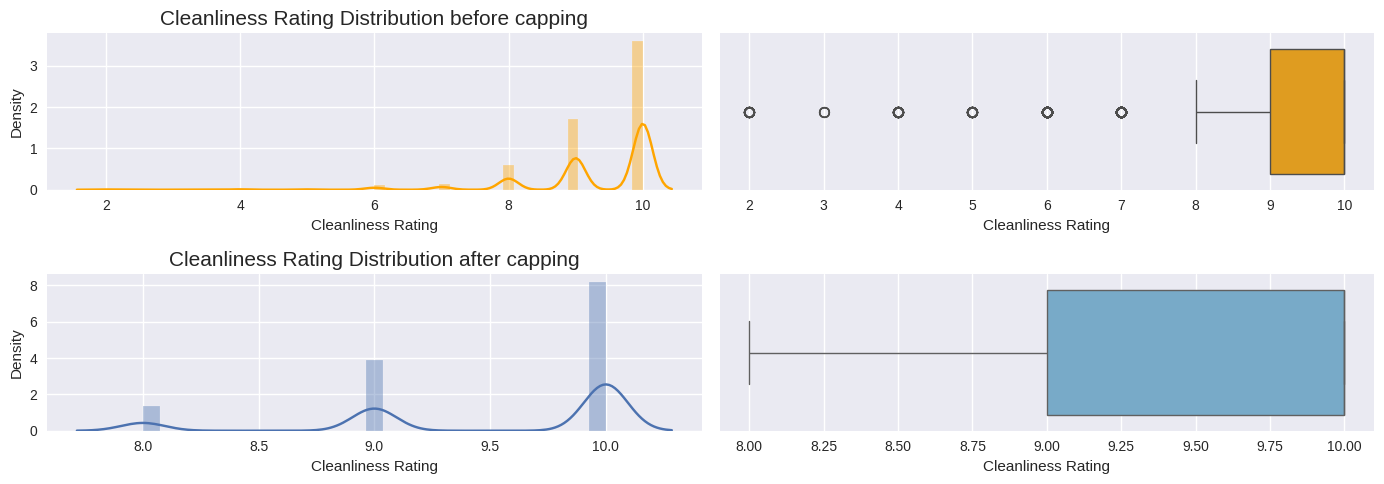

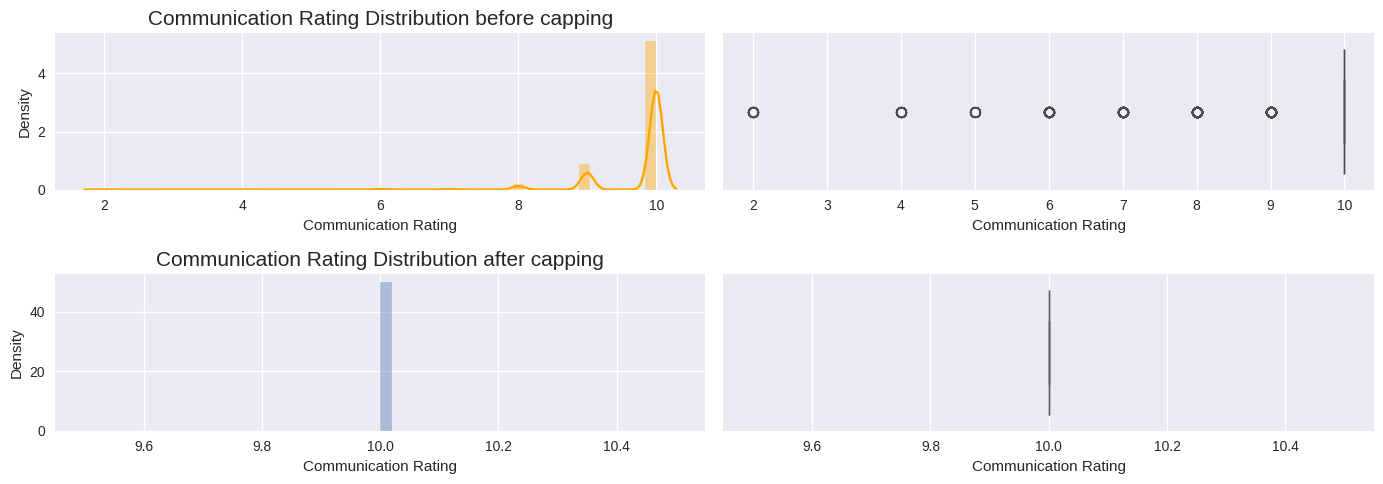

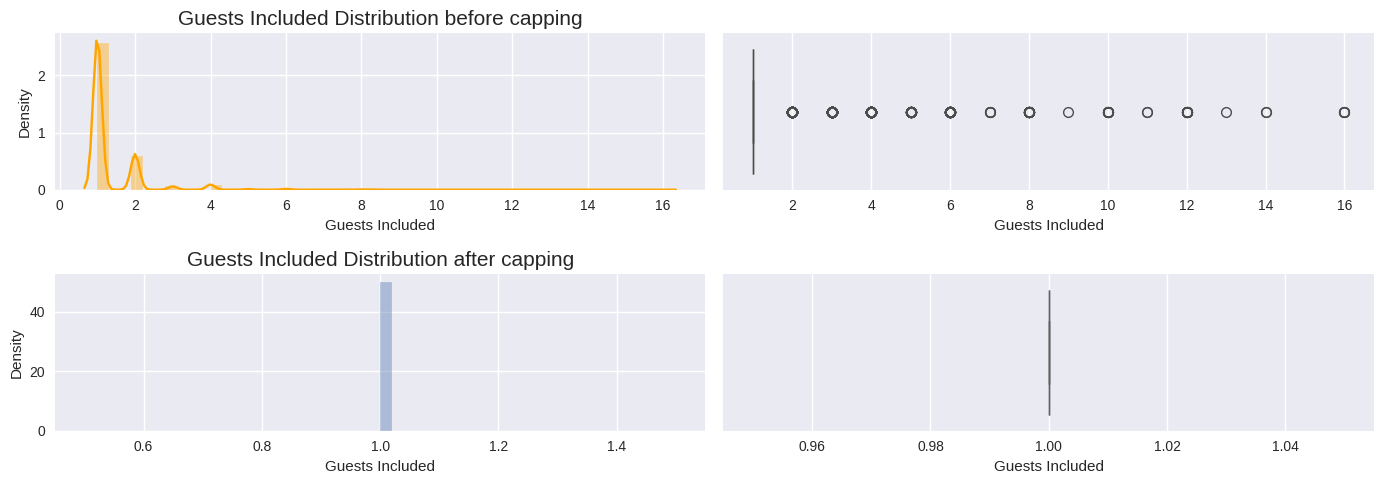

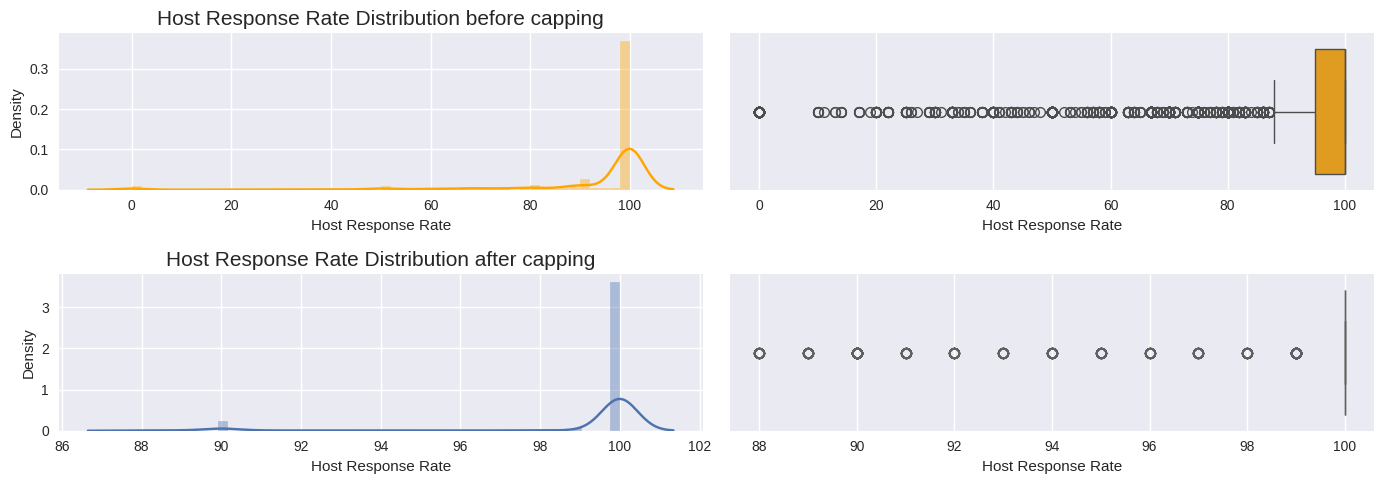

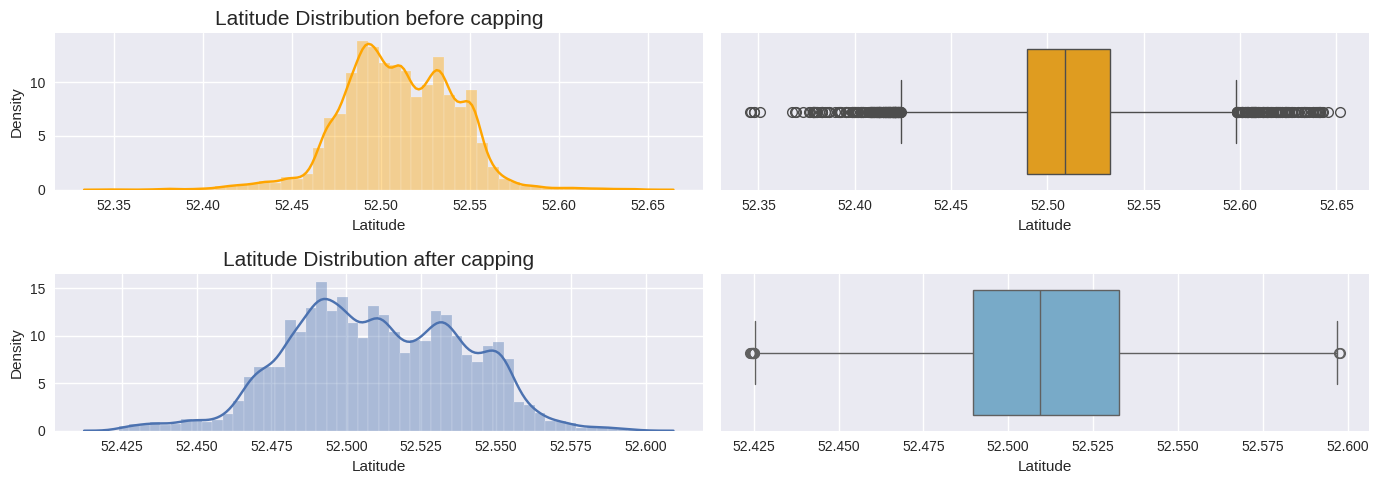

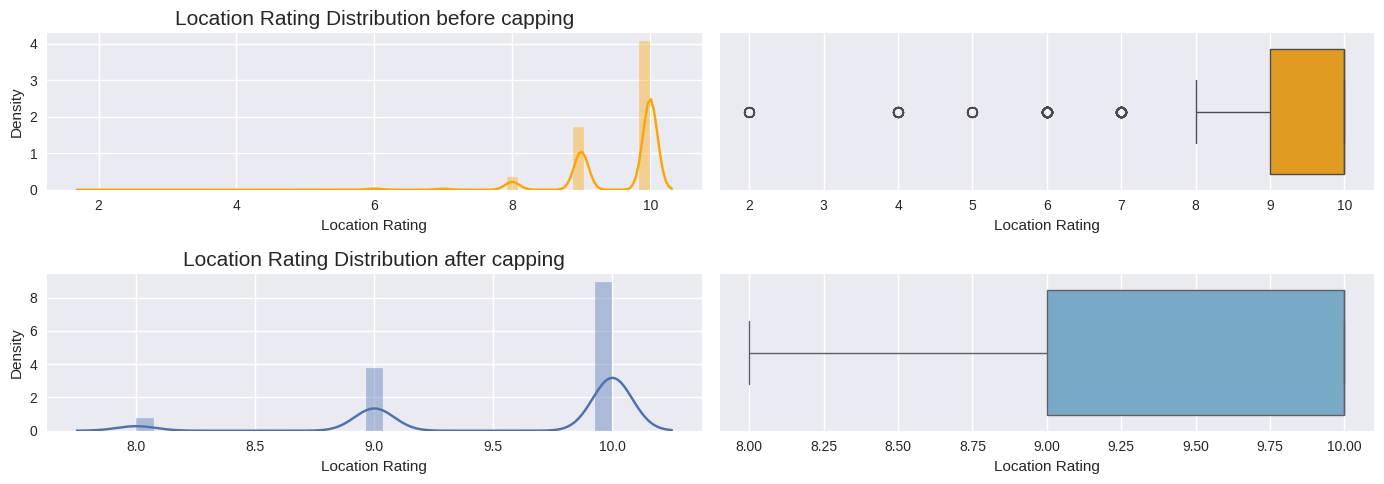

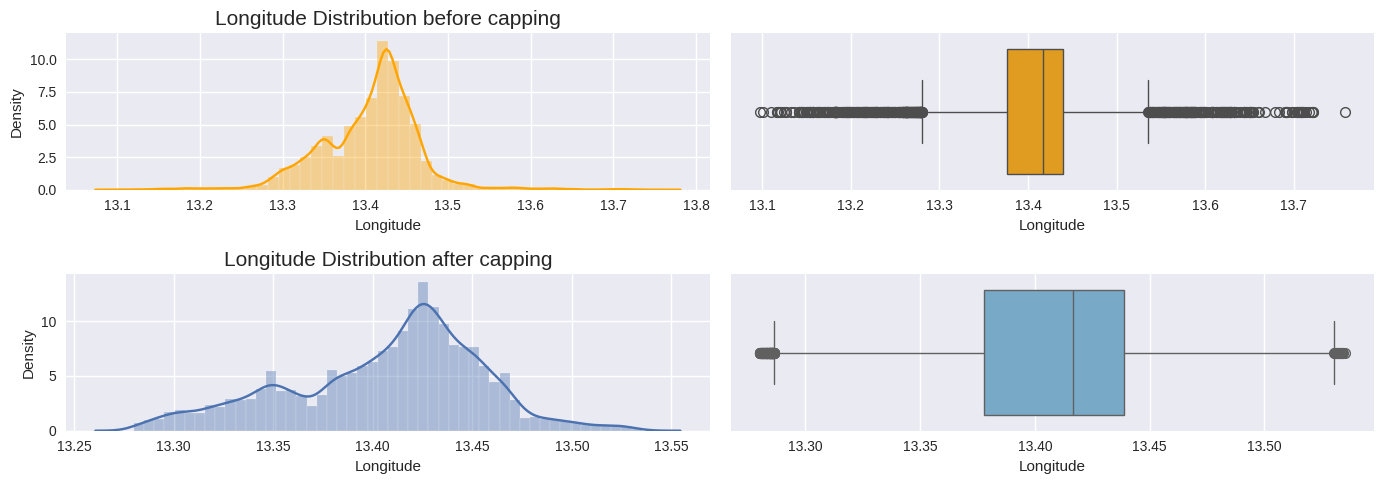

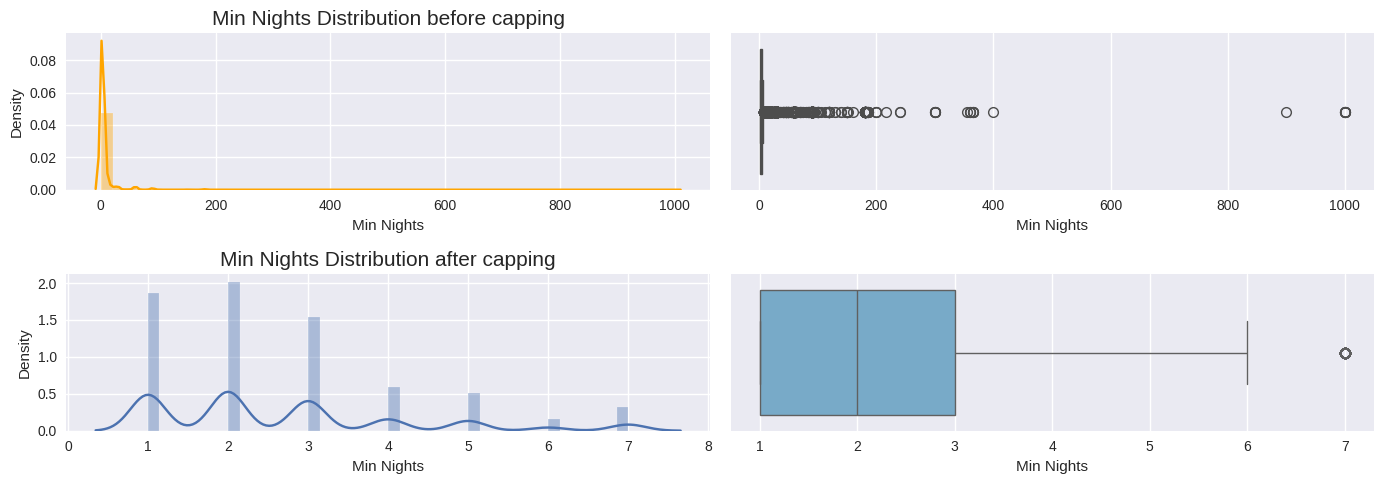

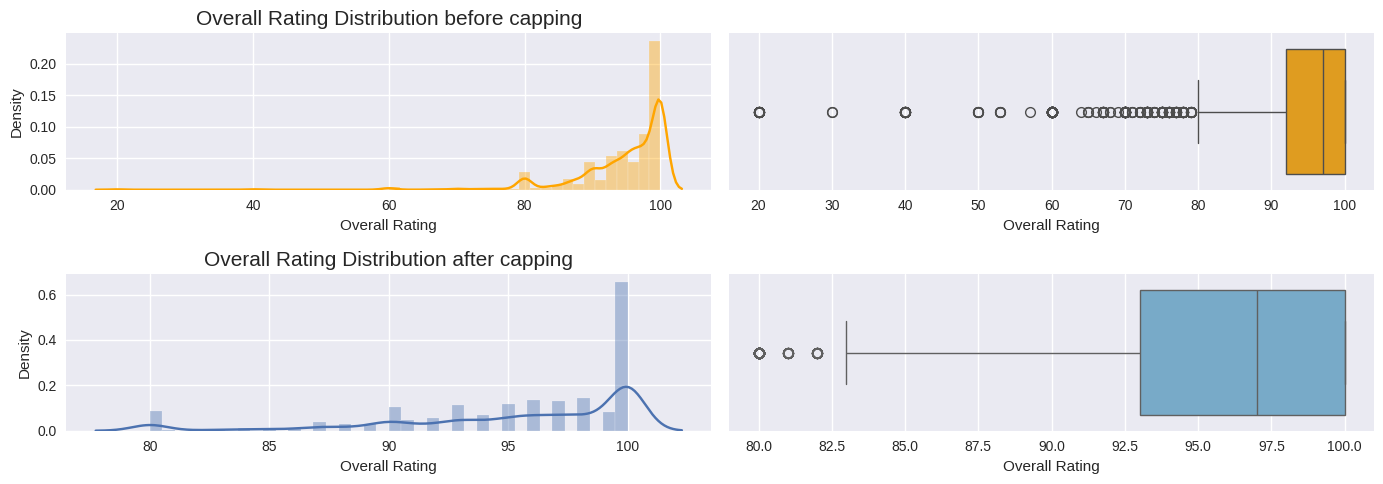

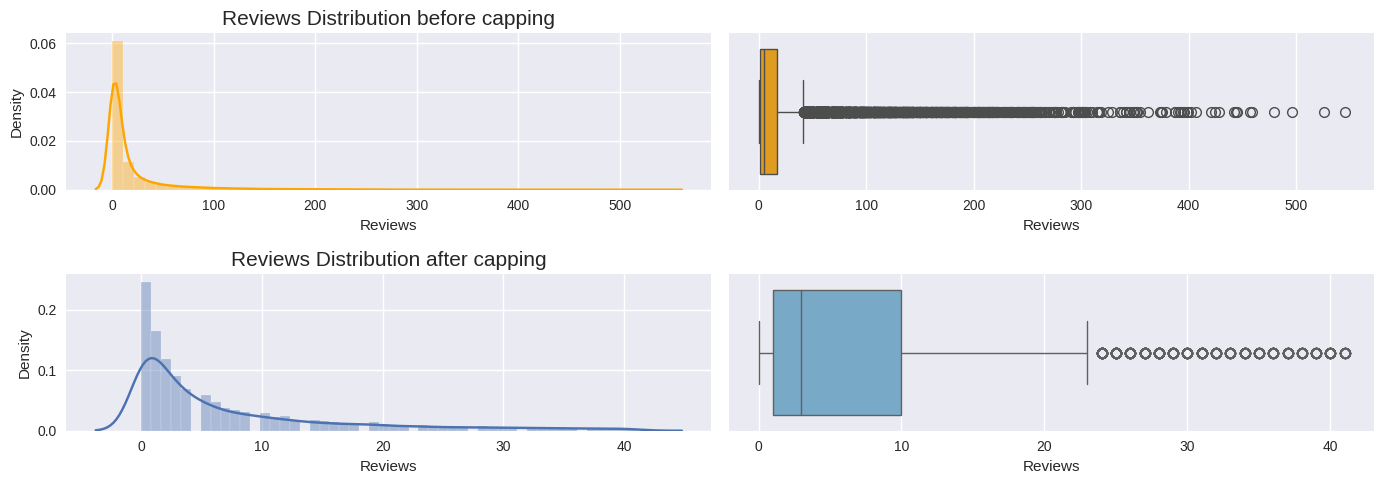

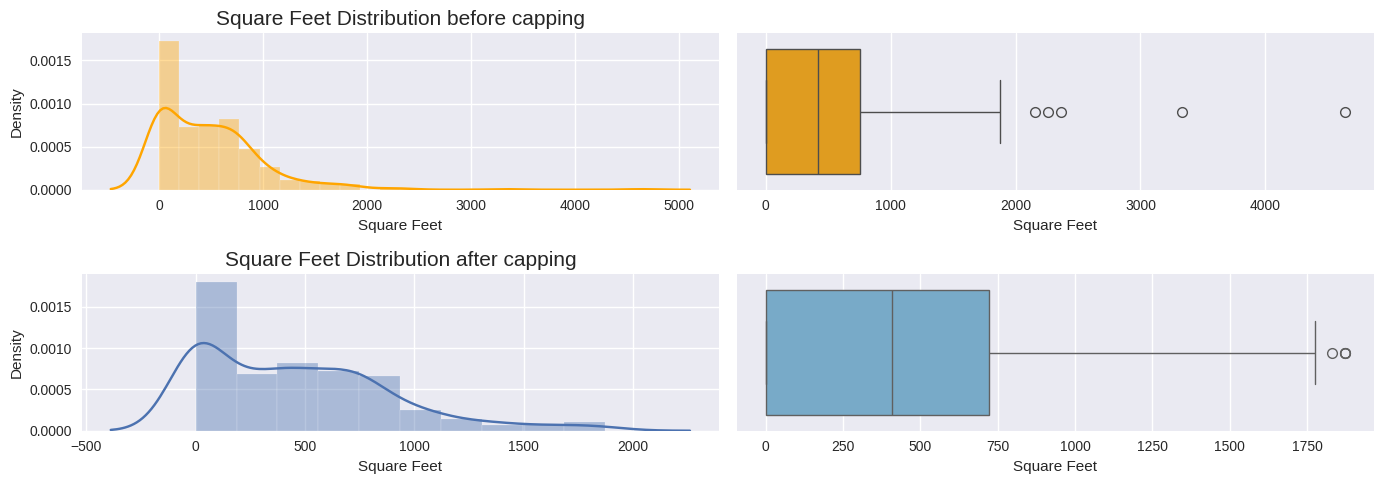

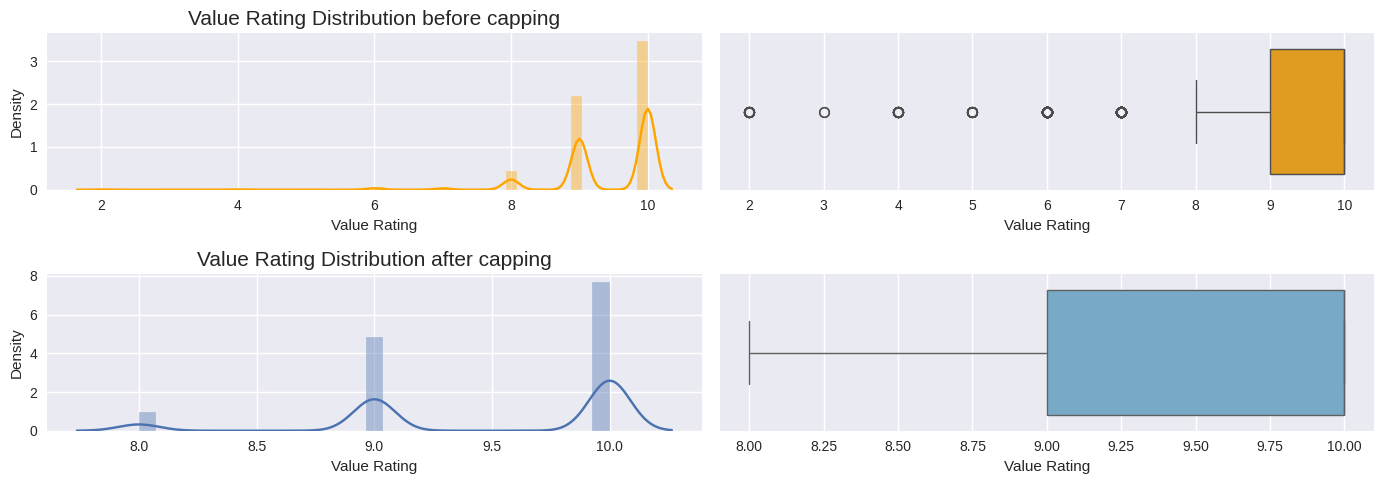

In [176]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(14,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna(), color='orange')
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), color='orange')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.index)

We clearly need to filter some features that either the feature distribution has changed significantly, or cases where removing outliers results with only one value.

Checking if distribution (Kolmogorov–Smirnov) and/or correlation has changed significantly:

In [177]:
corr_mattrix = df[['Price', 'Reviews']].corr(method='spearman')
corr_mattrix.Price.loc['Reviews']

0.08775901543190176

In [178]:
df['Price'].corr(df['Reviews'], method='spearman')

0.08775901543190176

In [179]:
### differences between two correlation in Python: https://github.com/psinger/CorrelationStats
### We will only take from the code the Fisher method for two-tailed test
### Z-test to Compare Two Correlations???
def cocor(x1,y1, x2,y2):
    xy1 = x1.corr(y1, method='spearman')
    xy2 = x2.corr(y2, method='spearman')
    n1 = len(x1)
    n2 = len(x2)
    xy_z = 0.5 * np.log((1 + xy1)/(1 - xy1))
    ab_z = 0.5 * np.log((1 + xy2)/(1 - xy2))
    if n2 is None:
        n2 = n1
    se_diff_r = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    diff = xy_z - ab_z
    z_score = abs(diff / se_diff_r)
    p_value = (1 - norm.cdf(z_score)) * 2
    return z_score, p_value

In [180]:
c=df_num_non_dummy.drop(columns=['Price'])
names=c.columns
#Creating df that reflects the correlation change
out_df= pd.DataFrame(columns=['feature','outliers_cnt','distribution_changed','correlation_changed'])

#A copy of numeric df
no_outliers=df_num_non_dummy.copy()
np.seterr(divide='ignore', invalid='ignore')
for i in names:
#     df with outliers
    out=df[i]
#     df with out outliers
    non=df[i].loc[new_df_outliers[i]==0]
#     lable with outliers
    price_out=df['Price']
#     lable with out outliers
    price_non=df['Price'].loc[new_df_outliers[i]==0]
#     cocor pvalue
    p, pvalue = cocor(out,price_out, non,price_non)
    cor_change=np.where(pvalue<0.05,'+','-')
#     outliers count
    mv=df_outliers.sum()
#    ks pvalue
    pval=ks_2samp(out, non)[1]
    dist_change=np.where(pval<0.05,'+','-')
    out_df = pd.concat([out_df, pd.DataFrame([{'feature':i,'outliers_cnt':mv,'distribution_changed':dist_change,'correlation_changed': cor_change}])], ignore_index=True)
out_df.head(20)

,feature,outliers_cnt,distribution_changed,correlation_changed
0,Accomodates,Accomodates 2116 Accuracy Rating ...,-,-
1,Accuracy Rating,Accomodates 2116 Accuracy Rating ...,-,-
2,Bathrooms,Accomodates 2116 Accuracy Rating ...,-,-
3,Bedrooms,Accomodates 2116 Accuracy Rating ...,-,-
4,Beds,Accomodates 2116 Accuracy Rating ...,-,-
5,Checkin Rating,Accomodates 2116 Accuracy Rating ...,-,-
6,Cleanliness Rating,Accomodates 2116 Accuracy Rating ...,-,-
7,Communication Rating,Accomodates 2116 Accuracy Rating ...,-,-
8,Guests Included,Accomodates 2116 Accuracy Rating ...,-,-
9,Host Response Rate,Accomodates 2116 Accuracy Rating ...,-,-


In [181]:
#All 'Yes' Vars in the 'Drop'colums shall be deleted, since the infect correlation and distribution.
#We don't want to delete vars that will change the distribution
out_df['drop']='yes'
out_df.loc[(out_df.distribution_changed=='+')& (out_df.correlation_changed=='+'),'drop'] = 'no'
out_df

,feature,outliers_cnt,distribution_changed,correlation_changed,drop
0,Accomodates,Accomodates 2116 Accuracy Rating ...,-,-,yes
1,Accuracy Rating,Accomodates 2116 Accuracy Rating ...,-,-,yes
2,Bathrooms,Accomodates 2116 Accuracy Rating ...,-,-,yes
3,Bedrooms,Accomodates 2116 Accuracy Rating ...,-,-,yes
4,Beds,Accomodates 2116 Accuracy Rating ...,-,-,yes
5,Checkin Rating,Accomodates 2116 Accuracy Rating ...,-,-,yes
6,Cleanliness Rating,Accomodates 2116 Accuracy Rating ...,-,-,yes
7,Communication Rating,Accomodates 2116 Accuracy Rating ...,-,-,yes
8,Guests Included,Accomodates 2116 Accuracy Rating ...,-,-,yes
9,Host Response Rate,Accomodates 2116 Accuracy Rating ...,-,-,yes


In [182]:
out_df.groupby('drop').size()

,0
drop,
yes,18


There are 20 features in total where removal of the outliers does not affect neither correlation nor distribution. And 17 features that shall be removed.

In [183]:
relevant_columns_features=out_df.loc[out_df['drop']=='yes']['feature']
relevant_columns_features

,feature
0,Accomodates
1,Accuracy Rating
2,Bathrooms
3,Bedrooms
4,Beds
5,Checkin Rating
6,Cleanliness Rating
7,Communication Rating
8,Guests Included
9,Host Response Rate


In [184]:
relevant_columns_features.values

array(['Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms', 'Beds',
       'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Min Nights', 'Overall Rating',
       'Reviews', 'Square Feet', 'Value Rating'], dtype=object)

Will only select the following columns to remove

In [185]:
remove_outliers=['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']
remove_outliers

['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']

Removing outleirs that don't change correlation

In [224]:
manipulated_data= df.copy()
for index, row in df_outliers.iterrows():  # Iterate through df_outliers with index
    for col in remove_outliers:
        if row[col] == 1:
            manipulated_data.loc[index,col] = np.NaN ## 0  # Use the index from df_outliers

In [187]:
manipulated_data.columns

Index(['Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms', 'Beds',
       'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude', 'Location Rating',
       'Longitude', 'Min Nights', 'Overall Rating', 'Price', 'Reviews',
       'Square Feet', 'Value Rating', 'Comments', 'Host Response Time',
       'Is Superhost', 'neighbourhood', 'Neighborhood Group', 'Postal Code',
       'Is Exact Location', 'Property Type', 'Room Type', 'Instant Bookable',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

In [188]:
manipulated_data.to_csv('/content/drive/My Drive/Airbnb/manipulated_data_no_outleirs.csv')

# Missing Values

In [189]:
def missing_columns_df(df):
  df_nulls = df.copy()
  for col in df_nulls:
      if df_nulls[col].isna().sum() == 0:
          del df_nulls[col]
  return df_nulls

df_nulls = missing_columns_df(manipulated_data)
df_nulls

,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Location Rating,Overall Rating,Square Feet,Value Rating,Comments,Host Response Time
0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,0.0,9.0,100.0,NaN,10.0,I really enjoyed staying at Micha and Nadja's ...,within a day
1,9.0,1.0,1.0,2.0,9.0,9.0,9.0,0.0,10.0,92.0,720.0,9.0,"excellent stay, i would highly recommend it. a...",within a day
2,10.0,1.0,1.0,2.0,10.0,10.0,10.0,100.0,10.0,96.0,NaN,10.0,I could not have asked for a better place to s...,within an hour
3,10.0,0.0,4.0,7.0,10.0,10.0,10.0,100.0,10.0,100.0,NaN,10.0,The host was very welcoming and hospitable. He...,within a day
4,10.0,1.0,0.0,1.0,9.0,10.0,10.0,100.0,9.0,93.0,NaN,9.0,"We had everything we needed, the apartment was...",within a day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,1.0,2.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,None,within a few hours
23532,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
23533,NaN,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
23534,NaN,1.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None


<Axes: >

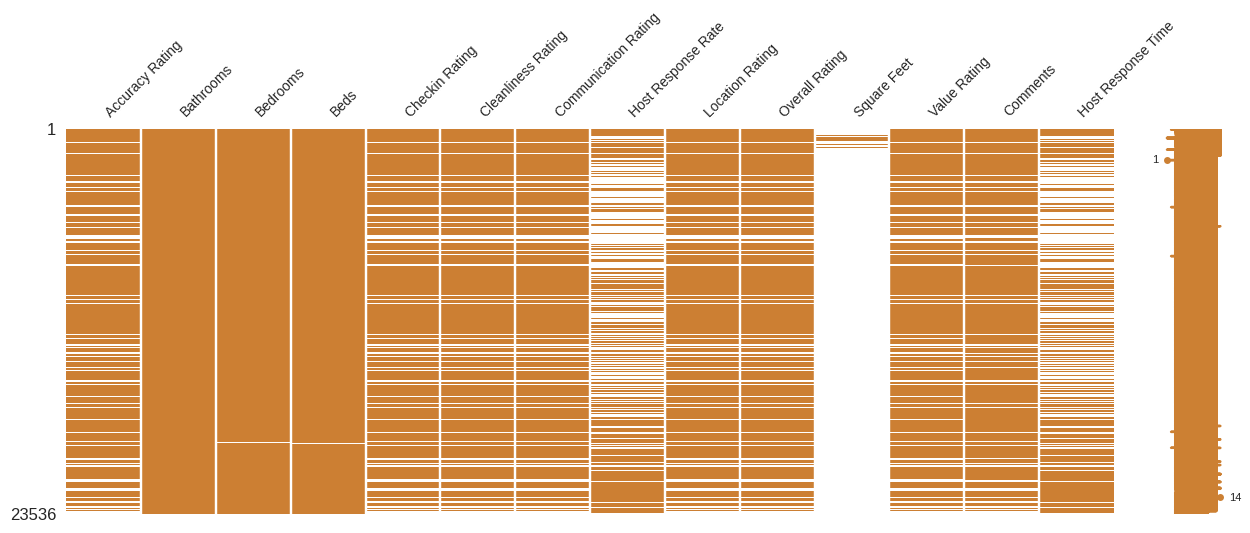

In [190]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

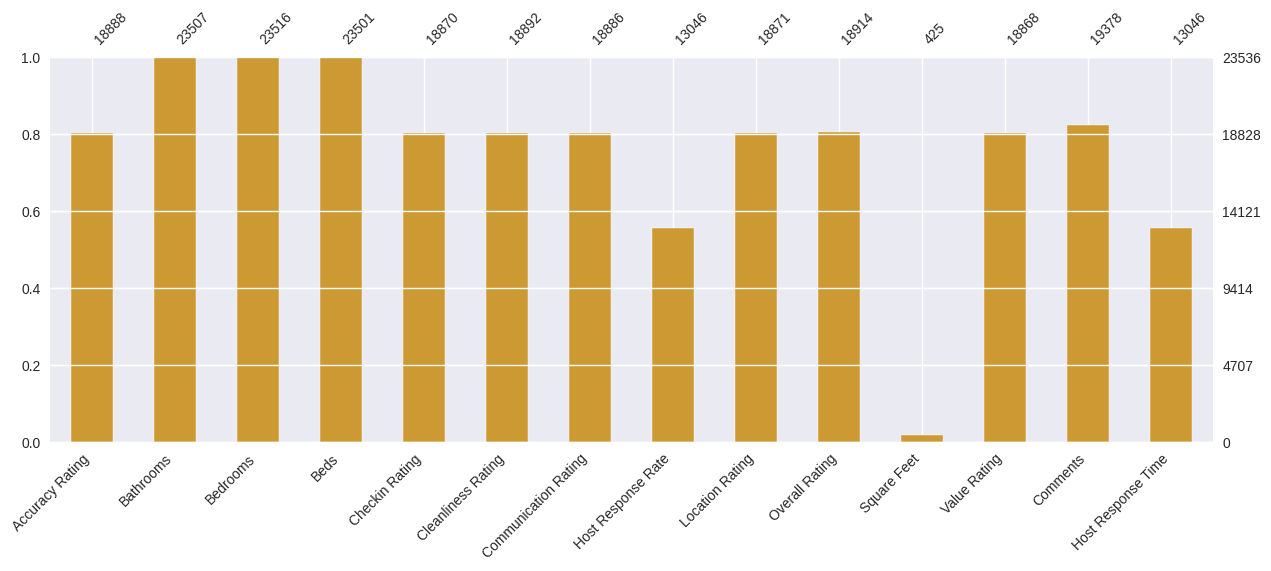

In [191]:
msno.bar(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.6, 0.2));

In [192]:
def missing_values_table(df):
  mis_val = df.isna().sum()
  mis_val_per = mis_val/len(df)*100
  mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
  mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
  mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,:] != 0].sort_values(
      '% of Total Values', ascending=False).round(1)
  return mis_val_table_ren_columns

mis_val_table_ren_columns = missing_values_table(df_nulls)
mis_val_table_ren_columns

,Missing Values,% of Total Values
Square Feet,23111,98.2
Host Response Rate,10490,44.6
Host Response Time,10490,44.6
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6


Creating a dataframe with missing values as 1 and existing values as 0:

In [193]:
df_missing_data = manipulated_data.isin([np.nan])
df_missing_data = df_missing_data.astype('int')
df_missing_data

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Square Feet,Value Rating,Comments,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Property Type Reduced,Postal Code Reduced
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,0,1,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
23532,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
23533,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
23534,0,1,0,0,0,1,1,1,0,1,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0


Creating df including numeric features of the later data - manipulated_data

In [194]:
#Selecting numeric data
numeric_manipulated_data = manipulated_data.select_dtypes(include=[np.number])
numeric_manipulated_data.columns

Index(['Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms', 'Beds',
       'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude', 'Location Rating',
       'Longitude', 'Min Nights', 'Overall Rating', 'Price', 'Reviews',
       'Square Feet', 'Value Rating'],
      dtype='object')

Exploring data the segnificunce of distribution change:

In [243]:
#le = preprocessing.LabelEncoder()
MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed', 'pval'])
#df[m] = le.fit_transform(df[m].astype(str))
m=numeric_manipulated_data.copy()
#m = manipulated_data._get_numeric_data().columns.dropna().unique()
np.seterr(divide='ignore', invalid='ignore')
for i in df_nulls:
    # and i in mis_val_table_ren_columns.index.tolist():
    # column with NULLS
        null = m['Latitude'] ##.loc[df_missing_data[i]==1]
    # column without NULLS
        non = m['Latitude'].loc[df_missing_data[i]==0]
    # target value with NULLS
        price_null = m['Price']
    # target value without NULLS
        price_non = price_null.loc[df_missing_data[i]==0]
        mv = df_missing_data[i].sum()
    # perform Kolmogorov-Smirnov test
        pval = ks_2samp(null, non)[1]
        dis_change = np.where(pval<0.05,'+','-')
        # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
        temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change, 'pval': pval}, index=[0])
        # Concatenate the temporary DataFrame to the final DataFrame
        MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
        MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]

        # Plot KDE for comparison
        # plt.figure(figsize=(10, 5))
        # sns.kdeplot(null, label="is NaN", fill=True, alpha=0.5, color='blue')
        # sns.kdeplot(non, label="is NOT NaN", fill=True, alpha=0.5, color='red')
        # plt.title(f"Distribution of Missingness of '{i}' , P-Value = {pval}, Missing= {mv}")
        # plt.legend()
        # plt.show()
MV_df_final

,Var,MV_pct,distribution_changed,pval
0,Accuracy Rating,4648,-,0.983938
1,Bathrooms,29,-,1.000000
2,Bedrooms,20,-,1.000000
3,Beds,35,-,1.000000
4,Checkin Rating,4666,-,0.981860
5,Cleanliness Rating,4644,-,0.983022
6,Communication Rating,4650,-,0.982322
7,Host Response Rate,10490,+,0.000041
8,Location Rating,4665,-,0.981617
9,Overall Rating,4622,-,0.982043


Original

In [228]:
# #le = preprocessing.LabelEncoder()
# MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed', 'pval'])
# #df[m] = le.fit_transform(df[m].astype(str))
# m=numeric_manipulated_data.copy()
# #m = manipulated_data._get_numeric_data().columns.dropna().unique()
# np.seterr(divide='ignore', invalid='ignore')
# for i in m:
#     # and i in mis_val_table_ren_columns.index.tolist():
#     # column with NULLS
#         null = m[i]
#     # column without NULLS
#         non = m[i].loc[df_missing_data[i]==0]
#     # target value with NULLS
#         price_null = m['Price']
#     # target value without NULLS
#         price_non = price_null.loc[df_missing_data[i]==0]
#         mv = df_missing_data[i].sum()
#     # perform Kolmogorov-Smirnov test
#         pval = ks_2samp(null, non)[1]
#         dis_change = np.where(pval<0.05,'+','-')
#         # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
#         temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change, 'pval': pval}, index=[0])
#         # Concatenate the temporary DataFrame to the final DataFrame
#         MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
#         MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]

#         print(f"{i} --> null: {null.notna().sum()}, {null.shape} <---> non: {non.isna().sum()}, {non.shape}")
MV_df_final

Accomodates --> null: 23536, (23536,) <---> non: 0, (23536,)
Accuracy Rating --> null: 18888, (18888,) <---> non: 0, (18888,)
Bathrooms --> null: 23507, (23507,) <---> non: 0, (23507,)
Bedrooms --> null: 23516, (23516,) <---> non: 0, (23516,)
Beds --> null: 23501, (23501,) <---> non: 0, (23501,)
Checkin Rating --> null: 18870, (18870,) <---> non: 0, (18870,)
Cleanliness Rating --> null: 18892, (18892,) <---> non: 0, (18892,)
Communication Rating --> null: 18886, (18886,) <---> non: 0, (18886,)
Guests Included --> null: 23536, (23536,) <---> non: 0, (23536,)
Host Response Rate --> null: 13046, (13046,) <---> non: 0, (13046,)
Latitude --> null: 23536, (23536,) <---> non: 0, (23536,)
Location Rating --> null: 18871, (18871,) <---> non: 0, (18871,)
Longitude --> null: 23536, (23536,) <---> non: 0, (23536,)
Min Nights --> null: 23536, (23536,) <---> non: 0, (23536,)
Overall Rating --> null: 18914, (18914,) <---> non: 0, (18914,)
Price --> null: 23536, (23536,) <---> non: 0, (23536,)
Reviews

,Var,MV_pct,distribution_changed,pval
0,Accuracy Rating,4648,-,1.0
1,Bathrooms,29,-,1.0
2,Bedrooms,20,-,1.0
3,Beds,35,-,1.0
4,Checkin Rating,4666,-,1.0
5,Cleanliness Rating,4644,-,1.0
6,Communication Rating,4650,-,1.0
7,Host Response Rate,10490,-,1.0
8,Location Rating,4665,-,1.0
9,Overall Rating,4622,-,1.0


In [196]:
MV_df_final['drop']= 'Yes'
MV_df_final['MV_type']= 'MCAR/MAR'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'drop']='No'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'MV_type']='MNAR'
MV_df_final = MV_df_final[MV_df_final['MV_pct']>0].sort_values(by='MV_pct', ascending=False)
MV_df_final

,Var,MV_pct,distribution_changed,drop,MV_type
10,Square Feet,23111,-,Yes,MCAR/MAR
7,Host Response Rate,10490,-,Yes,MCAR/MAR
11,Value Rating,4668,-,Yes,MCAR/MAR
4,Checkin Rating,4666,-,Yes,MCAR/MAR
8,Location Rating,4665,-,Yes,MCAR/MAR
6,Communication Rating,4650,-,Yes,MCAR/MAR
0,Accuracy Rating,4648,-,Yes,MCAR/MAR
5,Cleanliness Rating,4644,-,Yes,MCAR/MAR
9,Overall Rating,4622,-,Yes,MCAR/MAR
3,Beds,35,-,Yes,MCAR/MAR


# Data Imputation

Although the columns were recommended for removal, we will go over teh columns one by one.

In [197]:
mis_val_table_ren_columns

,Missing Values,% of Total Values
Square Feet,23111,98.2
Host Response Rate,10490,44.6
Host Response Time,10490,44.6
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6


In [198]:
df_final = manipulated_data

In [199]:
manipulated_data.index[-1]

23535

In [200]:
manipulated_data.reset_index(drop=True, inplace=True)

In [201]:
df_nulls.columns

Index(['Accuracy Rating', 'Bathrooms', 'Bedrooms', 'Beds', 'Checkin Rating',
       'Cleanliness Rating', 'Communication Rating', 'Host Response Rate',
       'Location Rating', 'Overall Rating', 'Square Feet', 'Value Rating',
       'Comments', 'Host Response Time'],
      dtype='object')

1. We will delete 'Host Response Rate' since the missing is nearly 50%, however we will try to keep 'Host Response Time', cause we might use it later

In [202]:
del df_final['Host Response Rate']

2. We will categorize the missing values of dummies and categorial values: host_has_profile_pic, host_identity_verified, host_is_superhost, host_response_time, host_neighbourhood, host_location.
2.1 Transporing missing values of 3 categorial columns into additional categoey 'Missing'

In [203]:
#host_response_time
# df_final['Host Response Time'] = df_final.apply(lambda row: row['Host Response Time'] if type(row['Host Response Time']) == str else 'missing', axis=1)
df_final['Host Response Time'] = df_final['Host Response Time'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Host Response Time'].isnull().sum()

0

In [204]:
#host_response_time
df_final['Comments'] = df_final['Comments'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Comments'].isnull().sum()

0

In [205]:
missing_values_table(missing_columns_df(df_final))

,Missing Values,% of Total Values
Square Feet,23111,98.2
Value Rating,4668,19.8
Checkin Rating,4666,19.8
Location Rating,4665,19.8
Communication Rating,4650,19.8
Accuracy Rating,4648,19.7
Cleanliness Rating,4644,19.7
Overall Rating,4622,19.6
Beds,35,0.1
Bathrooms,29,0.1


### Use KNN

The rest of the data is below 40% missing. hense we can imput. we will use KNN

In [206]:
final_df = df_final.copy()
imp_cols = final_df.select_dtypes(include = ['float64', 'int64']).columns
imp_cols = [col for col in imp_cols if col not in ['Longitude', 'Latitude']]
imp_cols

['Accomodates',
 'Accuracy Rating',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Checkin Rating',
 'Cleanliness Rating',
 'Communication Rating',
 'Guests Included',
 'Location Rating',
 'Min Nights',
 'Overall Rating',
 'Price',
 'Reviews',
 'Square Feet',
 'Value Rating']

In [207]:
import math
math.sqrt(math.sqrt(len(final_df)))

12.386059554439452

In [208]:
from sklearn.impute import KNNImputer
# metric='nan_euclidean'
knn_imputer = KNNImputer(n_neighbors=11, metric='nan_euclidean')
imputed_data = pd.DataFrame(knn_imputer.fit_transform(final_df[imp_cols]),columns = imp_cols)

In [209]:
final_df[imp_cols] = imputed_data

<Axes: >

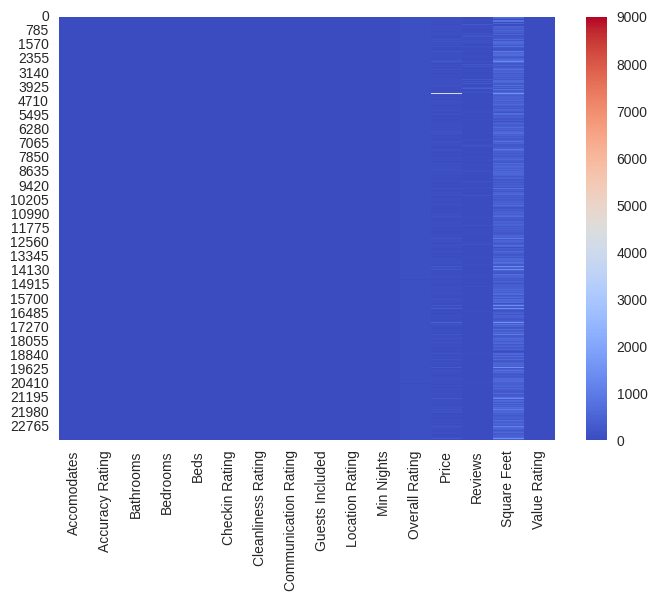

In [210]:
sns.heatmap(imputed_data, cmap="coolwarm")

In [211]:
imputed_data['Overall Rating'].notna().sum()

23536

In [212]:
print(f"df_final: {df_final.shape}, last_index: {df_final.index[-1]}")
print(f"final_df: {final_df.shape}, last_index: {final_df.index[-1]}")
print(f"imputed_data: {imputed_data.shape}, last_index: {imputed_data.index[-1]}")

df_final: (23536, 30), last_index: 23535
final_df: (23536, 30), last_index: 23535
imputed_data: (23536, 16), last_index: 23535


In [213]:
df_final.loc[df_final.index[-1]]

,23535
Accomodates,3.0
Accuracy Rating,NaN
Bathrooms,1.0
Bedrooms,2.0
Beds,2.0
Checkin Rating,NaN
Cleanliness Rating,NaN
Communication Rating,NaN
Guests Included,1.0
Latitude,52.54929


In [214]:
# imputed_data.dropna(inplace=True)

In [215]:
imputed_data

,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Location Rating,Min Nights,Overall Rating,Price,Reviews,Square Feet,Value Rating
0,2.0,10.000000,1.0,1.0,1.0,10.000000,10.000000,10.000000,1.0,9.000000,2.0,100.000000,17.0,7.0,403.090909,10.000000
1,4.0,9.000000,1.0,1.0,2.0,9.000000,9.000000,9.000000,2.0,10.000000,0.0,92.000000,90.0,144.0,720.000000,9.000000
2,2.0,10.000000,1.0,1.0,2.0,10.000000,10.000000,10.000000,1.0,10.000000,2.0,96.000000,33.0,229.0,277.818182,10.000000
3,0.0,10.000000,0.0,4.0,7.0,10.000000,10.000000,10.000000,5.0,10.000000,6.0,100.000000,180.0,6.0,837.545455,10.000000
4,1.0,10.000000,1.0,0.0,1.0,9.000000,10.000000,10.000000,1.0,9.000000,0.0,93.000000,70.0,23.0,477.545455,9.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,3.0,10.000000,1.0,1.0,2.0,10.000000,9.272727,9.636364,1.0,9.272727,0.0,96.363636,48.0,0.0,321.818182,9.272727
23532,2.0,8.909091,1.0,2.0,2.0,9.636364,8.000000,9.636364,2.0,8.545455,5.0,90.909091,30.0,0.0,392.818182,8.909091
23533,1.0,9.818182,0.0,1.0,1.0,9.272727,9.272727,9.454545,1.0,9.090909,2.0,98.181818,17.0,0.0,354.727273,8.545455
23534,0.0,8.818182,1.0,3.0,4.0,9.363636,9.000000,9.363636,1.0,9.090909,2.0,88.181818,52.0,0.0,293.545455,8.636364


In [216]:
# final_df.loc[23531]
# final_df.iloc[23531]
final_df.loc[final_df.index[-1]]
final_df.index[-1]

23535

In [217]:
imputed_data.loc[imputed_data.index[-1]]
imputed_data.index[-1]

23535

In [218]:
df_final.shape, imputed_data.index[-1]

((23536, 30), 23535)

In [219]:
final_df.shape

(23536, 30)

In [220]:
imputed_data.shape, final_df.shape

((23536, 16), (23536, 30))

<Axes: >

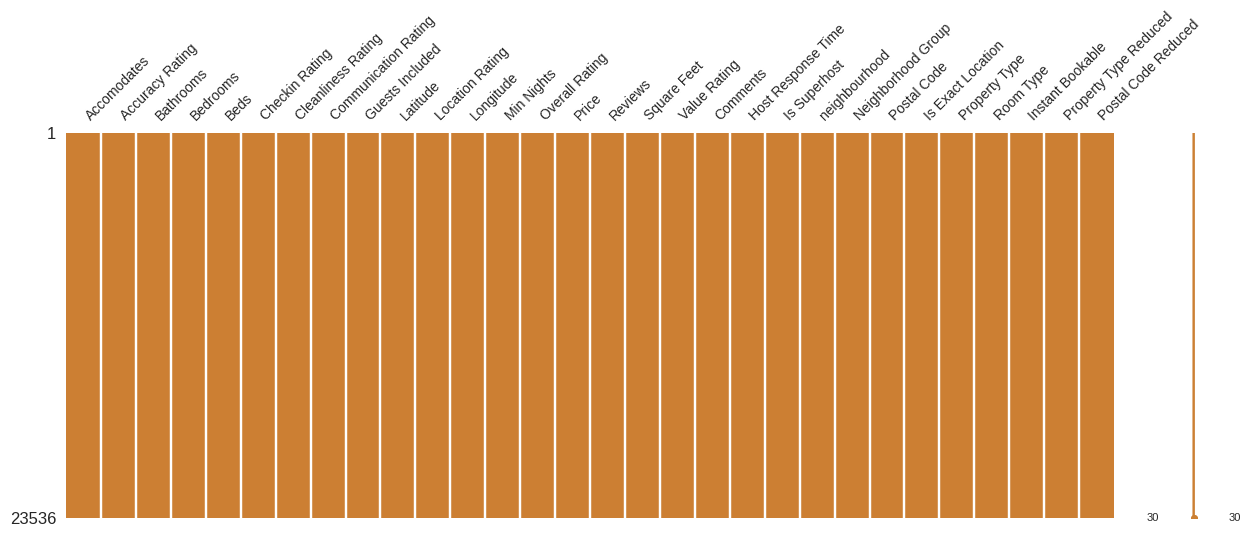

In [221]:
msno.matrix(final_df, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

# Next to Aggregation and Feature Engineering

In [222]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [223]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()

# Candidate for Trash